### [Mastering Financial Visualization with Matplotlib & Seaborn — Part 2](https://medium.com/@simplifiedzone/943cef10c771)

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Set the Seaborn theme for better aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelweight"] = "bold"

sns.set_theme(style="whitegrid")

%autosave 10

Autosaving every 10 seconds


#### **Histograms (Visualizing Risk)**

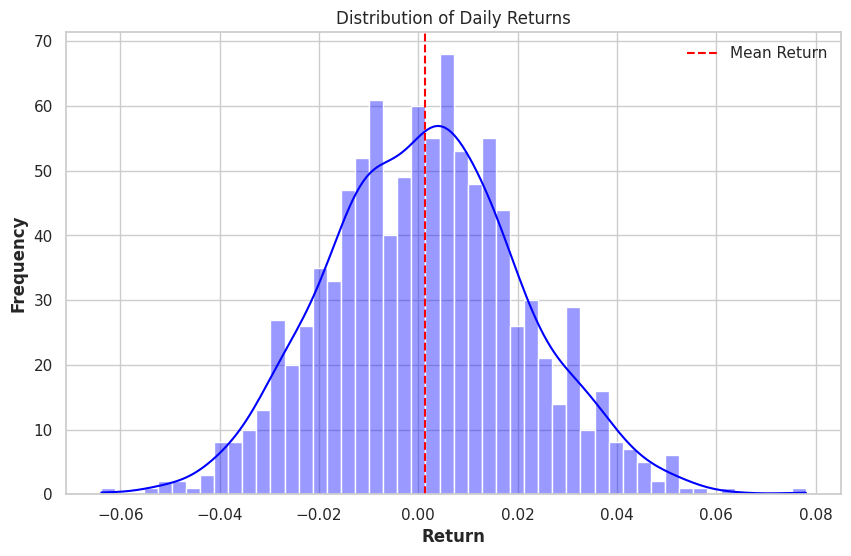

In [2]:
# Generate synthetic returns (Normal distribution)
np.random.seed(42)
returns = np.random.normal(0.001, 0.02, 1000) # Mean=0.1%, Vol=2%, 1000 days

# Create Figure
plt.figure(figsize=(10, 6))

# Plot Histogram with KDE
# bins=50: Divide data into 50 "buckets"
# kde=True: Draw the smooth curve line
sns.histplot(returns, bins=50, kde=True, color='blue', alpha=0.4)

plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

# Add a vertical line for the Mean
plt.axvline(np.mean(returns), color='red', linestyle='--', label='Mean Return')
plt.legend()

plt.show()

#### **Heatmaps (Correlation Matrices)**

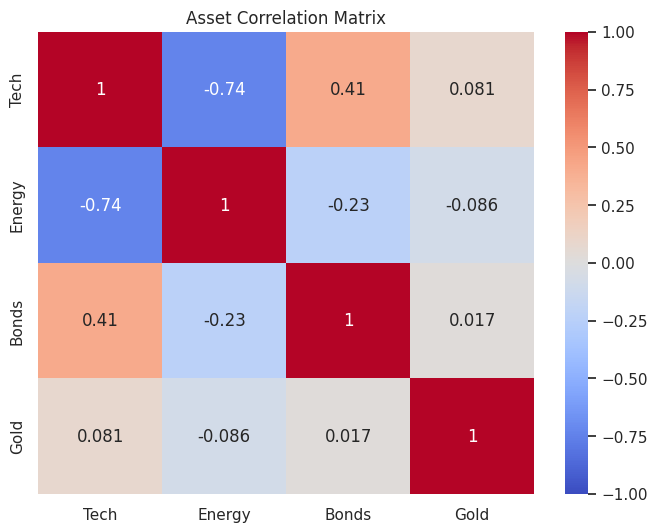

In [3]:
# Create a sample Portfolio DataFrame
data = {
    'Tech': np.random.normal(0, 1, 100),
    'Energy': np.random.normal(0, 1, 100),
    'Bonds': np.random.normal(0, 0.2, 100), # Lower volatility
    'Gold': np.random.normal(0, 0.5, 100)
}
df = pd.DataFrame(data)

# Introduce relationships
# Energy moves opposite to Tech
df['Energy'] = -0.5 * df['Tech'] + np.random.normal(0, 0.5, 100)

# Bonds are safe, slightly positive with everything
df['Bonds'] = df['Bonds'] + 0.1 * df['Tech']

# 1. Calculate the Correlation Matrix
corr_matrix = df.corr()

# 2. Plot the Heatmap
plt.figure(figsize=(8, 6))

# annot=True: Write the number inside the box
# cmap='coolwarm': Blue for negative (cool), Red for positive (warm)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Asset Correlation Matrix")
plt.show()

#### **Box Plots (Volatility Comparison)**

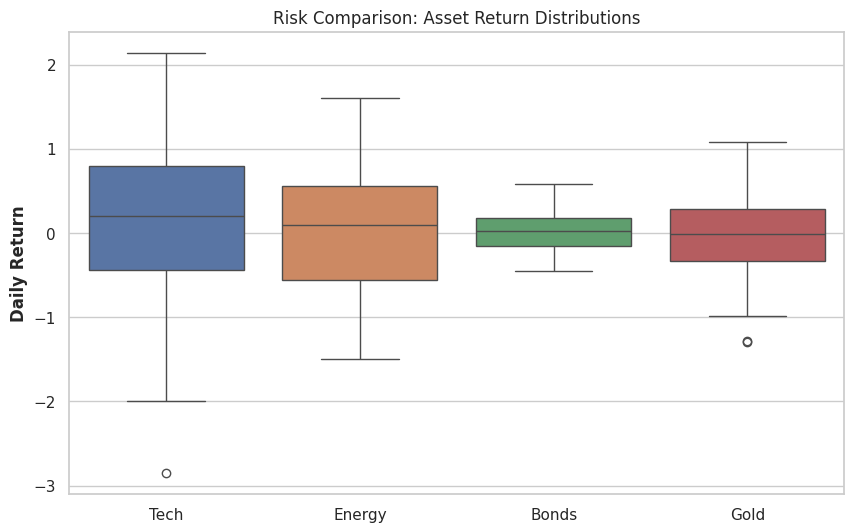

In [4]:
# Using the same dataframe 'df' from above

plt.figure(figsize=(10, 6))

# Draw Boxplot
sns.boxplot(data=df)

plt.title("Risk Comparison: Asset Return Distributions")
plt.ylabel("Daily Return")
plt.show()

#### **Financial Specialities (Candlestick Charts)**

In [5]:
!pip install -q mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.1 MB/s eta 0:00:00


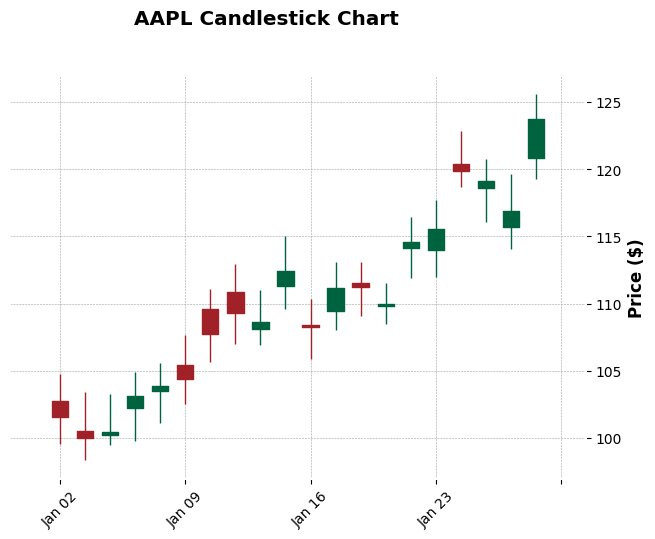

In [6]:
import mplfinance as mpf

# 1. Generate Synthetic OHLC Data
dates = pd.date_range(start='2023-01-01', periods=20, freq='B')
close = np.linspace(100, 120, 20) + np.random.normal(0, 2, 20)
open_p = close + np.random.normal(0, 1, 20)
high = np.maximum(open_p, close) + np.random.normal(2, 0.5, 20)
low = np.minimum(open_p, close) - np.random.normal(2, 0.5, 20)
volume = np.random.randint(1000, 5000, 20)

data = pd.DataFrame({
    'Open': open_p, 'High': high, 'Low': low, 'Close': close, 'Volume': volume
}, index=dates)

# 2. The Basic Candlestick Plot
# type='candle': Draws standard candles (Green=Up, Red=Down)
# style='charles': A popular financial style (Green/Red)
mpf.plot(data, type='candle', style='charles', title="AAPL Candlestick Chart", ylabel="Price ($)")

#### **Adding Technical Indicators (Moving Averages)**

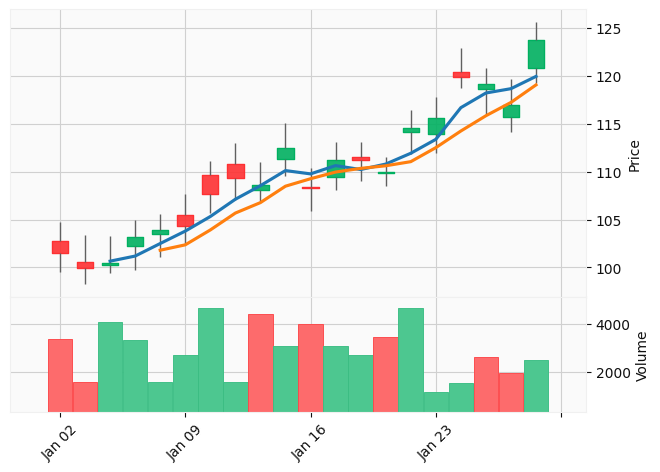

In [7]:
# Plot Candles + 3-day and 5-day Moving Averages + Volume
mpf.plot(data, type='candle', style='yahoo', mav=(3, 5), volume=True)

Generating Dashboard...


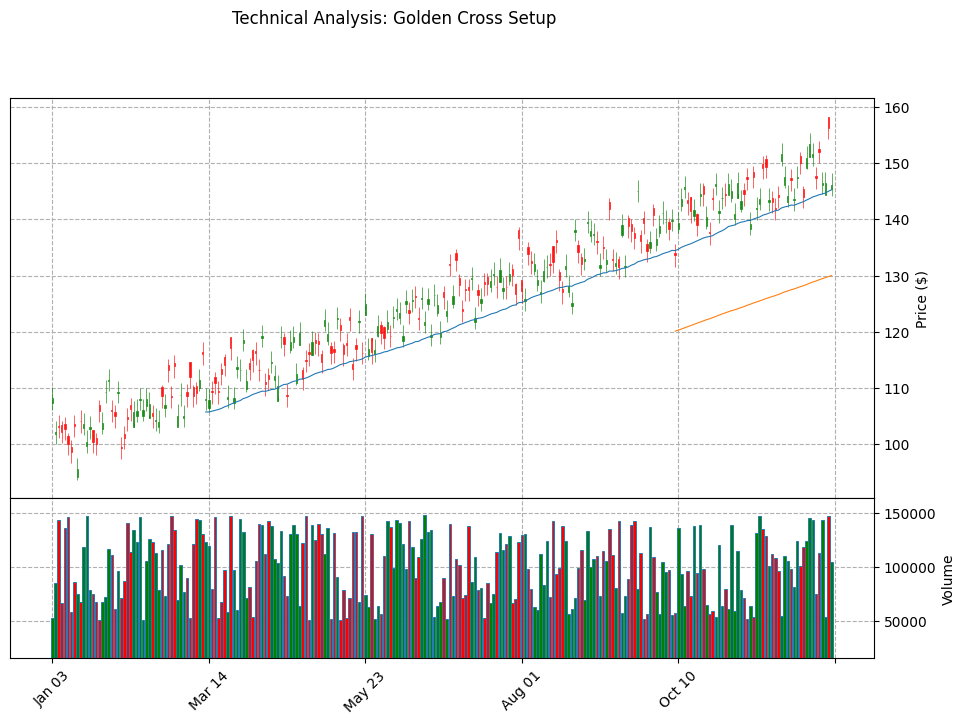

In [8]:
def create_dashboard():
    # --- Step 1: Generate 1 Year of Data ---
    np.random.seed(101)
    dates = pd.date_range(start='2022-01-01', periods=250, freq='B')

    # Create a trend with volatility
    price_trend = np.linspace(100, 150, 250)
    noise = np.random.normal(0, 3, 250)
    close = price_trend + noise

    # Create OHLC variations based on Close
    df = pd.DataFrame({
        'Open': close + np.random.normal(0, 1, 250),
        'Close': close,
        'High': close + 2,
        'Low': close - 2,
        'Volume': np.random.randint(50000, 150000, 250)
    }, index=dates)

    # --- Step 2: Define Plot Style ---
    # We create a custom style that looks like a Bloomberg Terminal
    mc = mpf.make_marketcolors(up='green', down='red', edge='i', wick='i', volume='in', inherit=True)
    s  = mpf.make_mpf_style(marketcolors=mc, gridstyle='--', y_on_right=True)

    # --- Step 3: Plot with Moving Averages ---
    # mav=(50, 200): Automatically calculates and plots the 50 and 200 SMA
    # volume=True: Adds the volume bars at the bottom
    # show_nontrading=False: Hides weekends to close gaps

    print("Generating Dashboard...")
    mpf.plot(df,
             type='candle',
             style=s,
             title="Technical Analysis: Golden Cross Setup",
             ylabel='Price ($)',
             ylabel_lower='Volume',
             mav=(50, 200),
             volume=True,
             figsize=(12, 8))

# Run the project
create_dashboard()